In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score
 )

# Reduce run-to-run variation before TensorFlow is imported.
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT_3D = Path('Single Activity/3D data')
NEW_SAMPLES_ROOT = Path('Single Activity/New_samples')

ACTIVITIES = ['Sitting', 'Standing', 'Waving', 'Walking']
TRAIN_DISTS = ['1 m', '2 m', '3 m']
TEST_DISTS = ['4 m', '5 m']
ALL_DISTS = TRAIN_DISTS + TEST_DISTS

# ── Sequence hyperparameters ──────────────────────────────────────────────────
WINDOW_SIZE = 25
STRIDE = 5
TRIM_START_FRAMES = 0
NUM_CLASSES = len(ACTIVITIES)

print(f'TF version : {tf.__version__}')
print(f'Activities : {ACTIVITIES}')
print(f'Train dists: {TRAIN_DISTS}')
print(f'Test  dists: {TEST_DISTS}')
print(f'Window size: {WINDOW_SIZE} frames  |  Stride: {STRIDE}')
print(f'Trim start frames for Sitting/Standing: {TRIM_START_FRAMES}')

TF version : 2.21.0
Activities : ['Sitting', 'Standing', 'Waving', 'Walking']
Train dists: ['1 m', '2 m', '3 m']
Test  dists: ['4 m', '5 m']
Window size: 25 frames  |  Stride: 5
Trim start frames for Sitting/Standing: 0


## 2. Data Loading & Per-Frame Feature Extraction

- `Single Activity/3D data`
- `Single Activity/New_samples`

The point-cloud CSV files were normalized to one shared schema across both roots:

- `timestamp_s, frame_number, point_index, x, y, z`
- `doppler, range, azimuth_deg, elevation_deg, snr, noise`

Angle definitions used in the standardized files are:

- `azimuth_deg = deg(atan2(y, x))`
- `elevation_deg = deg(atan2(z, sqrt(x^2 + y^2)))`

The model still trains on 1 m, 2 m, and 3 m, and tests on 4 m and 5 m.
The `Random` folder is not used.
All recordings from the same activity and distance are accumulated together after loading.

In [5]:
from IPython.display import display

FEATURE_COLS = [
    'point_count', 'mean_x', 'std_x', 'std_y', 'mean_z', 'std_z',
    'mean_doppler', 'std_doppler', 'min_doppler', 'max_doppler', 'abs_doppler',
    'std_range', 'mean_azimuth', 'std_azimuth', 'mean_elevation', 'std_elevation',
    'mean_snr', 'mean_noise'
 ]
N_FEATURES = len(FEATURE_COLS)
print(f'Features ({N_FEATURES}): {FEATURE_COLS}')

def read_pointcloud(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()
    df = df.rename(columns={
        'aoa': 'azimuth_deg',
        'doppler_mps': 'doppler',
        'snr_db': 'snr',
        'noise_db': 'noise',
    })

    if 'range' not in df.columns:
        df['range'] = np.sqrt(df['x'] ** 2 + df['y'] ** 2 + df['z'] ** 2)
    if 'azimuth_deg' not in df.columns:
        df['azimuth_deg'] = np.degrees(np.arctan2(df['y'], df['x']))
    if 'elevation_deg' not in df.columns:
        df['elevation_deg'] = np.degrees(
            np.arctan2(df['z'], np.sqrt(df['x'] ** 2 + df['y'] ** 2))
        )

    return df[[
        'frame_number', 'x', 'y', 'z', 'doppler', 'range',
        'azimuth_deg', 'elevation_deg', 'snr', 'noise'
    ]]

def extract_frame_features(csv_path, activity, distance, source, sample_name, recording_id):
    df = read_pointcloud(csv_path)

    def agg(g):
        return pd.Series({
            'point_count': len(g),
            'mean_x': g['x'].mean(),
            'std_x': g['x'].std(ddof=0),
            'std_y': g['y'].std(ddof=0),
            'mean_z': g['z'].mean(),
            'std_z': g['z'].std(ddof=0),
            'mean_doppler': g['doppler'].mean(),
            'std_doppler': g['doppler'].std(ddof=0),
            'min_doppler': g['doppler'].min(),
            'max_doppler': g['doppler'].max(),
            'abs_doppler': g['doppler'].abs().mean(),
            'std_range': g['range'].std(ddof=0),
            'mean_azimuth': g['azimuth_deg'].mean(),
            'std_azimuth': g['azimuth_deg'].std(ddof=0),
            'mean_elevation': g['elevation_deg'].mean(),
            'std_elevation': g['elevation_deg'].std(ddof=0),
            'mean_snr': g['snr'].mean(),
            'mean_noise': g['noise'].mean(),
        })

    feat = (
        df.groupby('frame_number', sort=True)
          .apply(agg)
          .reset_index()
          .fillna(0)
    )
    feat['activity'] = activity
    feat['distance'] = distance
    feat['source'] = source
    feat['sample_name'] = sample_name
    feat['recording_id'] = recording_id
    return feat

def build_recording_features(distances):
    manifest_rows = []
    frame_tables = []
    recording_index = 1

    for act in ACTIVITIES:
        for dist in distances:
            base_path = DATA_ROOT_3D / act / dist / 'PointCloud_snr.csv'
            if base_path.exists():
                recording_id = f'rec_{recording_index:03d}'
                manifest_rows.append({
                    'activity': act,
                    'distance': dist,
                    'source': '3d_data',
                    'sample_name': 'base',
                    'csv_path': base_path,
                    'recording_id': recording_id,
                })
                frame_tables.append(
                    extract_frame_features(base_path, act, dist, '3d_data', 'base', recording_id)
                )
                recording_index += 1

            sample_root = NEW_SAMPLES_ROOT / act / dist.replace(' ', '')
            if sample_root.exists():
                for sample_dir in sorted(child for child in sample_root.iterdir() if child.is_dir()):
                    csv_path = sample_dir / 'PointCloud_snr.csv'
                    if csv_path.exists():
                        recording_id = f'rec_{recording_index:03d}'
                        manifest_rows.append({
                            'activity': act,
                            'distance': dist,
                            'source': 'new_samples',
                            'sample_name': sample_dir.name,
                            'csv_path': csv_path,
                            'recording_id': recording_id,
                        })
                        frame_tables.append(
                            extract_frame_features(
                                csv_path, act, dist, 'new_samples', sample_dir.name, recording_id
                            )
                        )
                        recording_index += 1

    feat_df = pd.concat(frame_tables, ignore_index=True)
    manifest = pd.DataFrame(manifest_rows)
    return feat_df, manifest

print('Loading training data  (1 m, 2 m, 3 m)...')
train_feat, train_manifest = build_recording_features(TRAIN_DISTS)
print(f'  {len(train_feat)} frames  |  {train_feat["activity"].value_counts().to_dict()}')

print('Loading test data      (4 m, 5 m)...')
test_feat, test_manifest = build_recording_features(TEST_DISTS)
print(f'  {len(test_feat)} frames  |  {test_feat["activity"].value_counts().to_dict()}')

Features (18): ['point_count', 'mean_x', 'std_x', 'std_y', 'mean_z', 'std_z', 'mean_doppler', 'std_doppler', 'min_doppler', 'max_doppler', 'abs_doppler', 'std_range', 'mean_azimuth', 'std_azimuth', 'mean_elevation', 'std_elevation', 'mean_snr', 'mean_noise']
Loading training data  (1 m, 2 m, 3 m)...
  4742 frames  |  {'Standing': 1386, 'Sitting': 1378, 'Waving': 1007, 'Walking': 971}
Loading test data      (4 m, 5 m)...
  3144 frames  |  {'Sitting': 920, 'Standing': 916, 'Walking': 665, 'Waving': 643}


## 3. Sliding-Window Sequence Construction

Each recording is converted into overlapping windows of `WINDOW_SIZE` consecutive frames.  
Windows are built **per-recording** (activity × distance) so boundaries do not cross recordings.

In [36]:
def build_windows(feat_df, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    For each recording, slide a window over frames and collect
    (sequence, label, distance, recording_id) tuples.

    Returns:
        X : ndarray  shape (N, window_size, N_FEATURES)
        y : ndarray  shape (N,)  - string activity labels
        d : ndarray  shape (N,)  - distance folder labels
        r : ndarray  shape (N,)  - recording ids
    """
    seqs, labels, dists, recording_ids = [], [], [], []

    for (act, dist, recording_id), grp in feat_df.groupby(['activity', 'distance', 'recording_id'], sort=False):
        grp = grp.sort_values('frame_number').reset_index(drop=True)

        if TRIM_START_FRAMES > 0 and act in ['Sitting', 'Standing'] and len(grp) > TRIM_START_FRAMES:
            grp = grp.iloc[TRIM_START_FRAMES:].reset_index(drop=True)

        values = grp[FEATURE_COLS].values
        total_frames = len(values)

        for start in range(0, total_frames - window_size + 1, stride):
            seqs.append(values[start:start + window_size])
            labels.append(act)
            dists.append(dist)
            recording_ids.append(recording_id)

    return (
        np.array(seqs, dtype=np.float32),
        np.array(labels),
        np.array(dists),
        np.array(recording_ids),
    )

X_train_raw, y_train_str, d_train, r_train = build_windows(train_feat)
X_test_raw, y_test_str, d_test, r_test = build_windows(test_feat)

print(f'Train windows: {X_train_raw.shape}   labels: {pd.Series(y_train_str).value_counts().to_dict()}')
print(f'Test  windows: {X_test_raw.shape}   labels: {pd.Series(y_test_str).value_counts().to_dict()}')

Train windows: (738, 25, 18)   labels: {'Sitting': 224, 'Standing': 224, 'Waving': 148, 'Walking': 142}
Test  windows: (486, 25, 18)   labels: {'Sitting': 148, 'Standing': 148, 'Walking': 97, 'Waving': 93}


## 4. Feature Normalisation & Label Encoding

X_train: (677, 25, 18)  y_train: (677, 4)
X_test : (358, 25, 18)   y_test : (358, 4)
Classes: [np.str_('Sitting'), np.str_('Standing'), np.str_('Walking'), np.str_('Waving')]


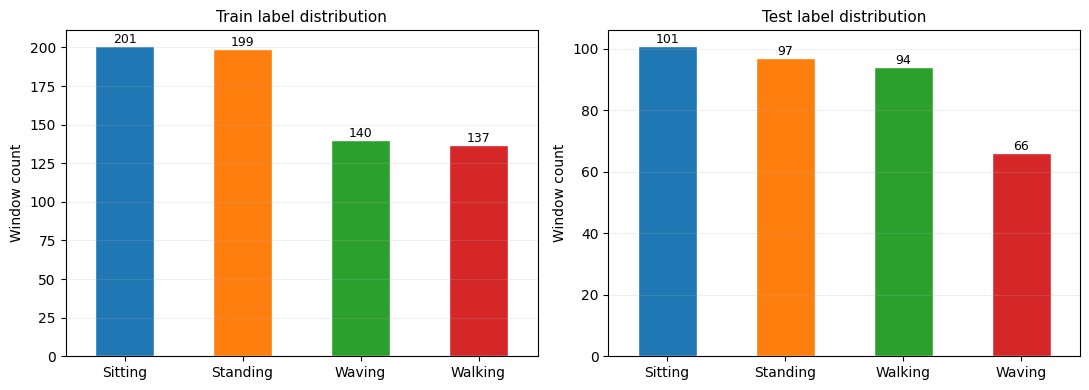

In [20]:
# ── Normalise feature-wise (fit ONLY on train data) ───────────────────────────
N_train, T, F = X_train_raw.shape
N_test = X_test_raw.shape[0]

scaler = StandardScaler()
X_train_2d = X_train_raw.reshape(-1, F)
X_test_2d = X_test_raw.reshape(-1, F)

scaler.fit(X_train_2d)
X_train = scaler.transform(X_train_2d).reshape(N_train, T, F).astype(np.float32)
X_test = scaler.transform(X_test_2d).reshape(N_test, T, F).astype(np.float32)

le = LabelEncoder()
le.fit(ACTIVITIES)

y_train_idx = le.transform(y_train_str)
y_test_idx = le.transform(y_test_str)
y_train_oh = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test_oh = to_categorical(y_test_idx, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train_oh.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test_oh.shape}')
print(f'Classes: {list(le.classes_)}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
    axes,
    [pd.Series(y_train_str).value_counts(), pd.Series(y_test_str).value_counts()],
    ['Train label distribution', 'Test label distribution']
 ):
    counts.plot.bar(ax=ax, color=sns.color_palette('tab10', NUM_CLASSES), edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Window count')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.2, axis='y')
    for patch in ax.patches:
        ax.annotate(
            str(int(patch.get_height())),
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha='center', va='bottom', fontsize=9
        )
plt.tight_layout()
plt.savefig('new_lstm_label_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. LSTM Model Definition

This now follows the Veena notebook structure again:

```
Input (25 frames × 18 features)
  └─ LSTM(64) → LayerNorm → Dropout(0.30)
       └─ Dense(32, relu) → Dropout(0.25)
            └─ Dense(4, softmax)
```

The only dataset change is in the loader: training and test recordings come from
both `3D data` and `New_samples`, not only `3D data`.

In [21]:
def build_lstm_model(window_size=WINDOW_SIZE, n_features=N_FEATURES, num_classes=NUM_CLASSES):
    inp = Input(shape=(window_size, n_features), name='frame_sequence')

    x = LSTM(64, return_sequences=False, name='lstm_1')(inp)
    x = LayerNormalization()(x)
    x = Dropout(0.30)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.25)(x)
    out = Dense(num_classes, activation='softmax', name='class_output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_Classifier_MergedData')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_model()
model.summary()

Model: "LSTM_Classifier_MergedData"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_sequence (InputLayer)     │ (None, 25, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,588 (92.14 KB)

 Trainable params: 23,588 (92.14 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

Same Veena-style training flow is used here:
- fit on all merged training windows
- use `validation_split=0.15` inside training
- stop early on validation loss
- reduce learning rate on plateau

In [22]:
EPOCHS = 100
BATCH_SIZE = 16
VAL_SPLIT = 0.15

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model_merged_data.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
]

history = model.fit(
    X_train,
    y_train_oh,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3878 - loss: 1.4060 - val_accuracy: 0.4216 - val_loss: 1.2372 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5530 - loss: 0.9783 - val_accuracy: 0.5196 - val_loss: 1.0060 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6365 - loss: 0.8017 - val_accuracy: 0.5686 - val_loss: 0.9593 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6470 - loss: 0.7481 - val_accuracy: 0.6176 - val_loss: 0.8731 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6904 - loss: 0.6771 - val_accuracy: 0.6569 - val_loss: 0.7649 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7322 - loss: 0.5982 - val_accuracy: 0.6667 - val_loss: 0.8225 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7548 - loss: 0.5351 - 

## 7. Overall Evaluation on Test Set (4 m + 5 m)

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test_idx

bal_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f'Balanced accuracy: {bal_acc:.4f}')
print(f'Macro F1-score   : {macro_f1:.4f}')

per_class_report = pd.DataFrame(
    classification_report(
        y_true, y_pred, target_names=le.classes_, zero_division=0, output_dict=True
    )
).T
per_class_metrics = (
    per_class_report.loc[le.classes_, ['precision', 'recall', 'f1-score', 'support']]
      .reset_index()
      .rename(columns={'index': 'activity'})
)

print('\nPer-class metrics:')
display(per_class_metrics)

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

Test loss    : 0.6977
Test accuracy: 0.6453
Balanced accuracy: 0.6478
Macro F1-score   : 0.6575

Per-class metrics:


,activity,precision,recall,f1-score,support
0,Sitting,0.503817,0.653465,0.568966,101.0
1,Standing,0.550562,0.505155,0.526882,97.0
2,Walking,1.000000,0.765957,0.867470,94.0
3,Waving,0.666667,0.666667,0.666667,66.0



Classification report:
              precision    recall  f1-score   support

     Sitting       0.50      0.65      0.57       101
    Standing       0.55      0.51      0.53        97
     Walking       1.00      0.77      0.87        94
      Waving       0.67      0.67      0.67        66

    accuracy                           0.65       358
   macro avg       0.68      0.65      0.66       358
weighted avg       0.68      0.65      0.65       358



## 8. Confusion Matrix

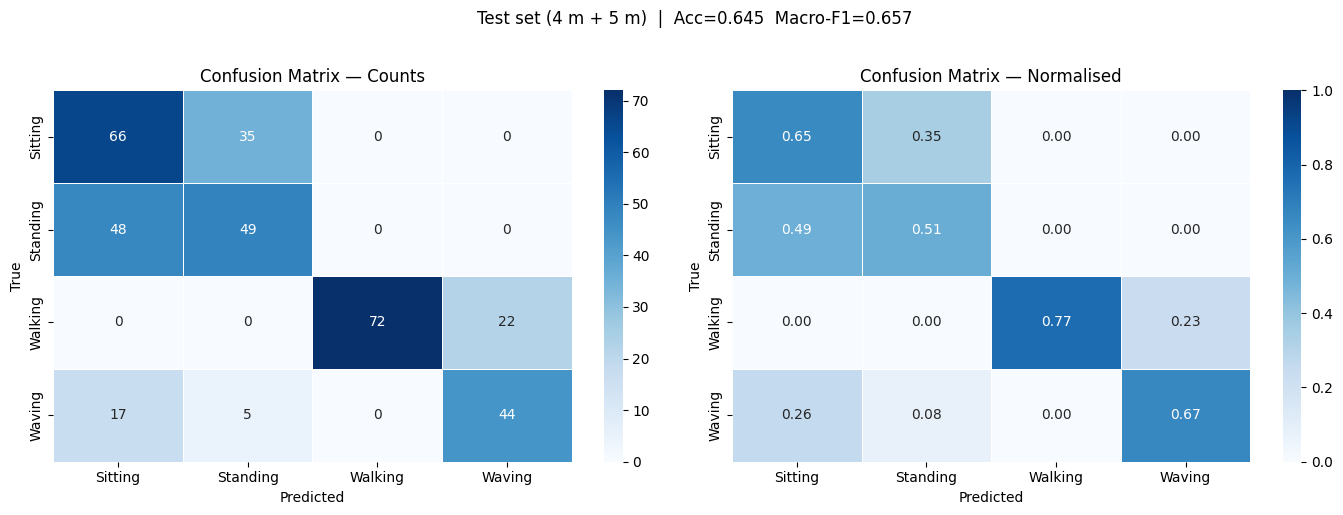

In [24]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=axes[0], linewidths=0.4
)
axes[0].set_title('Confusion Matrix — Counts', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    vmin=0, vmax=1, ax=axes[1], linewidths=0.4
)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle(
    f'Test set (4 m + 5 m)  |  Acc={test_acc:.3f}  Macro-F1={macro_f1:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('new_lstm_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per-Distance Performance Breakdown

In [25]:
print('=' * 55)
print('Per-Distance Performance on Test Set')
print('=' * 55)

dist_metrics = []
for dist in TEST_DISTS:
    mask = d_test == dist
    if mask.sum() == 0:
        continue

    yt_d = y_true[mask]
    yp_d = y_pred[mask]
    acc_d = accuracy_score(yt_d, yp_d)
    f1_d = f1_score(yt_d, yp_d, average='macro', zero_division=0)
    bal_d = balanced_accuracy_score(yt_d, yp_d)

    dist_metrics.append({
        'Distance': dist,
        'Samples': int(mask.sum()),
        'Accuracy': round(acc_d, 4),
        'Balanced Acc': round(bal_d, 4),
        'Macro F1': round(f1_d, 4),
    })

    print(f'\n  Distance: {dist}  ({mask.sum()} windows)')
    print(f'  Accuracy={acc_d:.4f}  BalAcc={bal_d:.4f}  MacroF1={f1_d:.4f}')
    print(classification_report(yt_d, yp_d, target_names=le.classes_, zero_division=0, digits=3))

dist_df = pd.DataFrame(dist_metrics)
print(dist_df.to_string(index=False))

Per-Distance Performance on Test Set

  Distance: 4 m  (179 windows)
  Accuracy=0.7486  BalAcc=0.7645  MacroF1=0.7593
              precision    recall  f1-score   support

     Sitting      0.640     0.653     0.646        49
    Standing      0.625     0.625     0.625        48
     Walking      1.000     0.809     0.894        47
      Waving      0.791     0.971     0.872        35

    accuracy                          0.749       179
   macro avg      0.764     0.765     0.759       179
weighted avg      0.760     0.749     0.750       179


  Distance: 5 m  (179 windows)
  Accuracy=0.5419  BalAcc=0.5219  MacroF1=0.5358
              precision    recall  f1-score   support

     Sitting      0.420     0.654     0.511        52
    Standing      0.463     0.388     0.422        49
     Walking      1.000     0.723     0.840        47
      Waving      0.435     0.323     0.370        31

    accuracy                          0.542       179
   macro avg      0.579     0.522     0.

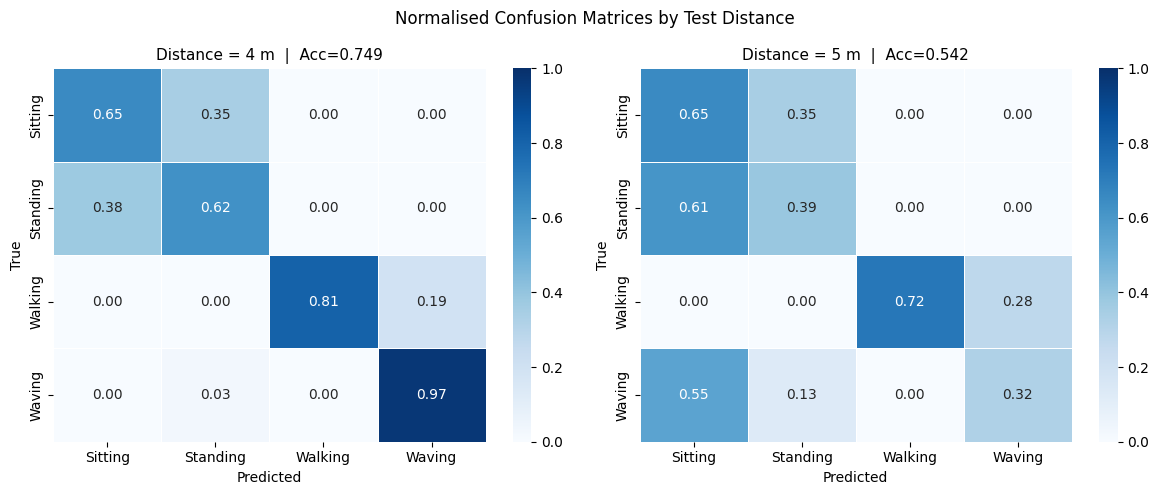

In [26]:
fig, axes = plt.subplots(1, len(TEST_DISTS), figsize=(6 * len(TEST_DISTS), 5))
if len(TEST_DISTS) == 1:
    axes = [axes]

for ax, dist in zip(axes, TEST_DISTS):
    mask = d_test == dist
    if mask.sum() == 0:
        ax.set_visible(False)
        continue

    cm_d = confusion_matrix(y_true[mask], y_pred[mask])
    cm_d_norm = cm_d.astype(float) / cm_d.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_d_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        vmin=0, vmax=1, ax=ax, linewidths=0.4
)
    acc_d = accuracy_score(y_true[mask], y_pred[mask])
    ax.set_title(f'Distance = {dist}  |  Acc={acc_d:.3f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices by Test Distance', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_cm_per_distance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Learning Curves

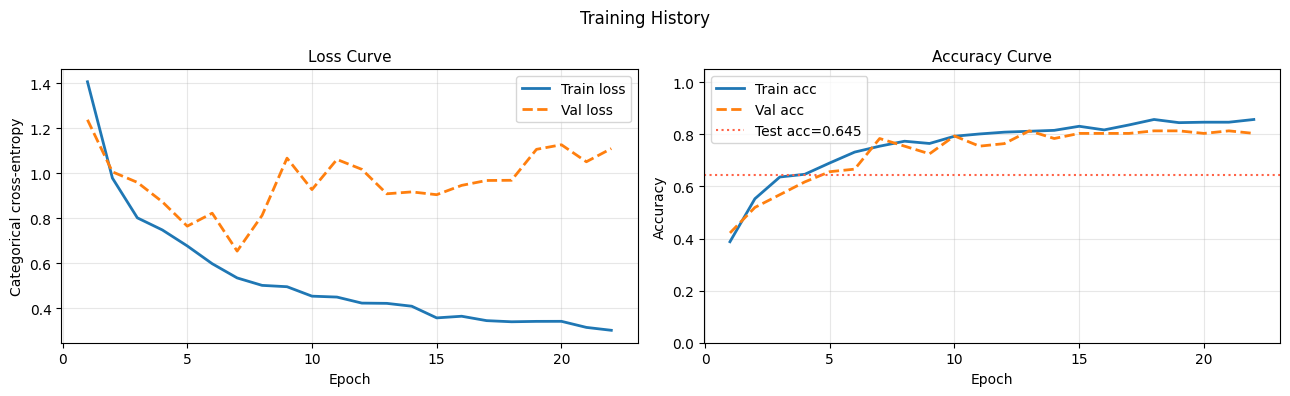

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_ran, history.history['loss'], label='Train loss', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val loss', linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical cross-entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['accuracy'], label='Train acc', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val acc', linewidth=2, linestyle='--')
axes[1].axhline(test_acc, color='tomato', linewidth=1.5, linestyle=':', label=f'Test acc={test_acc:.3f}')
axes[1].set_title('Accuracy Curve', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

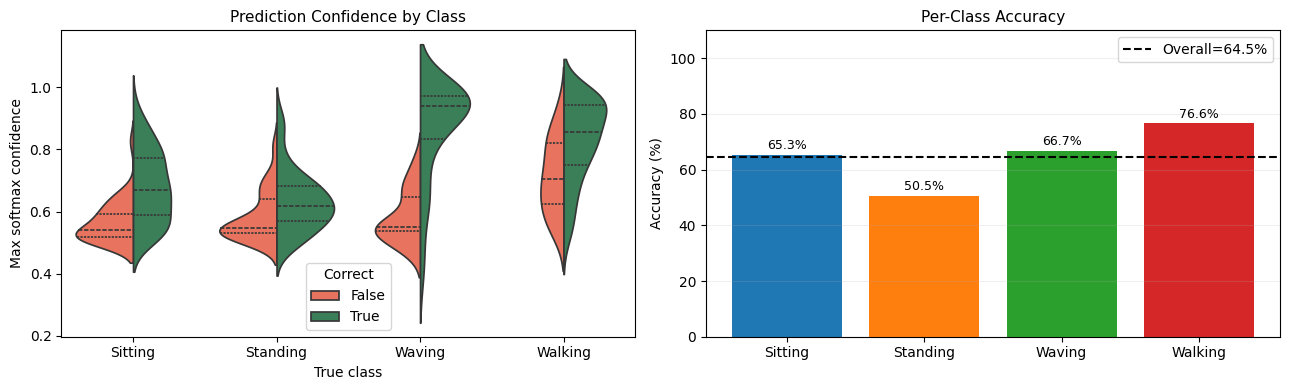

In [28]:
conf_df = pd.DataFrame({
    'true_label': [le.classes_[i] for i in y_true],
    'pred_label': [le.classes_[i] for i in y_pred],
    'confidence': y_prob.max(axis=1),
    'correct': y_true == y_pred,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.violinplot(
    data=conf_df, x='true_label', y='confidence',
    hue='correct', split=True, inner='quartile',
    palette={True: 'seagreen', False: 'tomato'}, ax=axes[0]
)
axes[0].set_title('Prediction Confidence by Class', fontsize=11)
axes[0].set_xlabel('True class')
axes[0].set_ylabel('Max softmax confidence')
axes[0].legend(title='Correct')

class_acc = conf_df.groupby('true_label')['correct'].mean().reindex(ACTIVITIES)
axes[1].bar(class_acc.index, class_acc.values * 100, color=sns.color_palette('tab10', NUM_CLASSES))
axes[1].axhline(test_acc * 100, color='black', linewidth=1.5, linestyle='--', label=f'Overall={test_acc * 100:.1f}%')
axes[1].set_title('Per-Class Accuracy', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(True, alpha=0.2, axis='y')
for i, value in enumerate(class_acc.values):
    axes[1].text(i, value * 100 + 2, f'{value * 100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('new_lstm_class_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Model & Scaler

## Appendix — Quick Inference on a New Recording

This helper follows the same merged-source feature pipeline used during training.
Pass a `PointCloud_snr.csv` path and it will return the majority-vote activity over all windows.

In [29]:
import joblib

ACCURACY_TO_SAVE = 0.80

if test_acc >= ACCURACY_TO_SAVE:
    model.save('new_data_lstm_classifier.keras')
    joblib.dump(scaler, 'new_data_feature_scaler.pkl')
    joblib.dump(le, 'new_data_label_encoder.pkl')
    print('Model saved -> new_data_lstm_classifier.keras')
    print('Scaler saved -> new_data_feature_scaler.pkl')
    print('Label encoder saved -> new_data_label_encoder.pkl')
else:
    print(f'Skipping save because test accuracy {test_acc:.4f} is below {ACCURACY_TO_SAVE:.2f}.')

print('\n' + '=' * 55)
print('TRAINING SUMMARY')
print('=' * 55)
print('  Dataset        : Single Activity (3D data + New_samples)')
print('  Model          : LSTM(64) + Dense(32)')
print(f'  Input shape    : ({WINDOW_SIZE}, {N_FEATURES})')
print(f'  Parameters     : {model.count_params():,}')
print(f'  Train windows  : {len(X_train)}')
print(f'  Test  windows  : {len(X_test)}')
print(f'  Test accuracy  : {test_acc:.4f}')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Balanced acc   : {bal_acc:.4f}')
print('=' * 55)

Skipping save because test accuracy 0.6453 is below 0.80.

TRAINING SUMMARY
  Dataset        : Single Activity (3D data + New_samples)
  Model          : LSTM(64) + Dense(32)
  Input shape    : (25, 18)
  Parameters     : 23,588
  Train windows  : 677
  Test  windows  : 358
  Test accuracy  : 0.6453
  Macro F1       : 0.6575
  Balanced acc   : 0.6478


In [34]:
def predict_activity_from_csv(csv_path, model=model, scaler=scaler, le=le, window_size=WINDOW_SIZE):
    df = read_pointcloud(Path(csv_path))

    feat = (
        df.groupby('frame_number', sort=True)
          .apply(
              lambda g: pd.Series({
                  'point_count': len(g),
                  'mean_x': g['x'].mean(),
                  'std_x': g['x'].std(ddof=0),
                  'std_y': g['y'].std(ddof=0),
                  'mean_z': g['z'].mean(),
                  'std_z': g['z'].std(ddof=0),
                  'mean_doppler': g['doppler'].mean(),
                  'std_doppler': g['doppler'].std(ddof=0),
                  'min_doppler': g['doppler'].min(),
                  'max_doppler': g['doppler'].max(),
                  'abs_doppler': g['doppler'].abs().mean(),
                  'std_range': g['range'].std(ddof=0),
                  'mean_azimuth': g['azimuth_deg'].mean(),
                  'std_azimuth': g['azimuth_deg'].std(ddof=0),
                  'mean_elevation': g['elevation_deg'].mean(),
                  'std_elevation': g['elevation_deg'].std(ddof=0),
                  'mean_snr': g['snr'].mean(),
                  'mean_noise': g['noise'].mean(),
              })
          )
          .reset_index()
          .fillna(0)
    )

    values = feat[FEATURE_COLS].to_numpy(dtype=np.float32)
    sequences = [
        values[start:start + window_size]
        for start in range(0, len(values) - window_size + 1, STRIDE)
    ]

    if not sequences:
        print(f'Recording too short: {len(values)} frames < window size {window_size}.')
        return None, None

    X_new = np.array(sequences, dtype=np.float32)
    X_new = scaler.transform(X_new.reshape(-1, N_FEATURES)).reshape(len(sequences), window_size, N_FEATURES)

    probs = model.predict(X_new, verbose=0)
    votes = np.argmax(probs, axis=1)
    final_idx = np.bincount(votes, minlength=NUM_CLASSES).argmax()
    final_label = le.classes_[final_idx]
    mean_conf = probs.max(axis=1).mean()
    return final_label, mean_conf

example_path = NEW_SAMPLES_ROOT / 'Walking' / '4m' / 'left' / 'PointCloud_snr.csv'
if example_path.exists():
    pred_label, pred_conf = predict_activity_from_csv(example_path)
    print(f'Example prediction -> label: {pred_label}, confidence: {pred_conf:.3f}')
else:
    print('Example inference skipped because the demo file was not found.')

Example inference skipped because the demo file was not found.
